In [13]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Sun Jun  7 11:20:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             31W /   70W |     117MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [16]:
import subprocess

subprocess.run(['kaggle', 'datasets', 'download', '-d',
                'vjchoudhary7/customer-segmentation-tutorial-in-python',
                '--unzip', '-p', '/kaggle/working/'],
               capture_output=True, text=True)

import os
print(os.listdir('/kaggle/working/'))

['Mall_Customers.csv', '.virtual_documents']


In [17]:
df = pd.read_csv('/kaggle/working/Mall_Customers.csv')
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.describe())

(200, 5)
   CustomerID  Gender  Age  Annual_Income  Spending_Score
0           1    Male   19             15              39
1           2    Male   21             15              81
2           3  Female   20             16               6
3           4  Female   23             16              77
4           5  Female   31             17              40
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64
       CustomerID         Age  Annual_Income  Spending_Score
count  200.000000  200.000000     200.000000      200.000000
mean   100.500000   38.850000      60.560000       50.200000
std     57.879185   13.969007      26.264721       25.823522
min      1.000000   18.000000      15.000000        1.000000
25%     50.750000   28.750000      41.500000       34.750000
50%    100.500000   36.000000      61.500000       50.000000
75%    150.250000   49.000000      78.000000       73.000000
max    200.000000   70.000000     137.0000

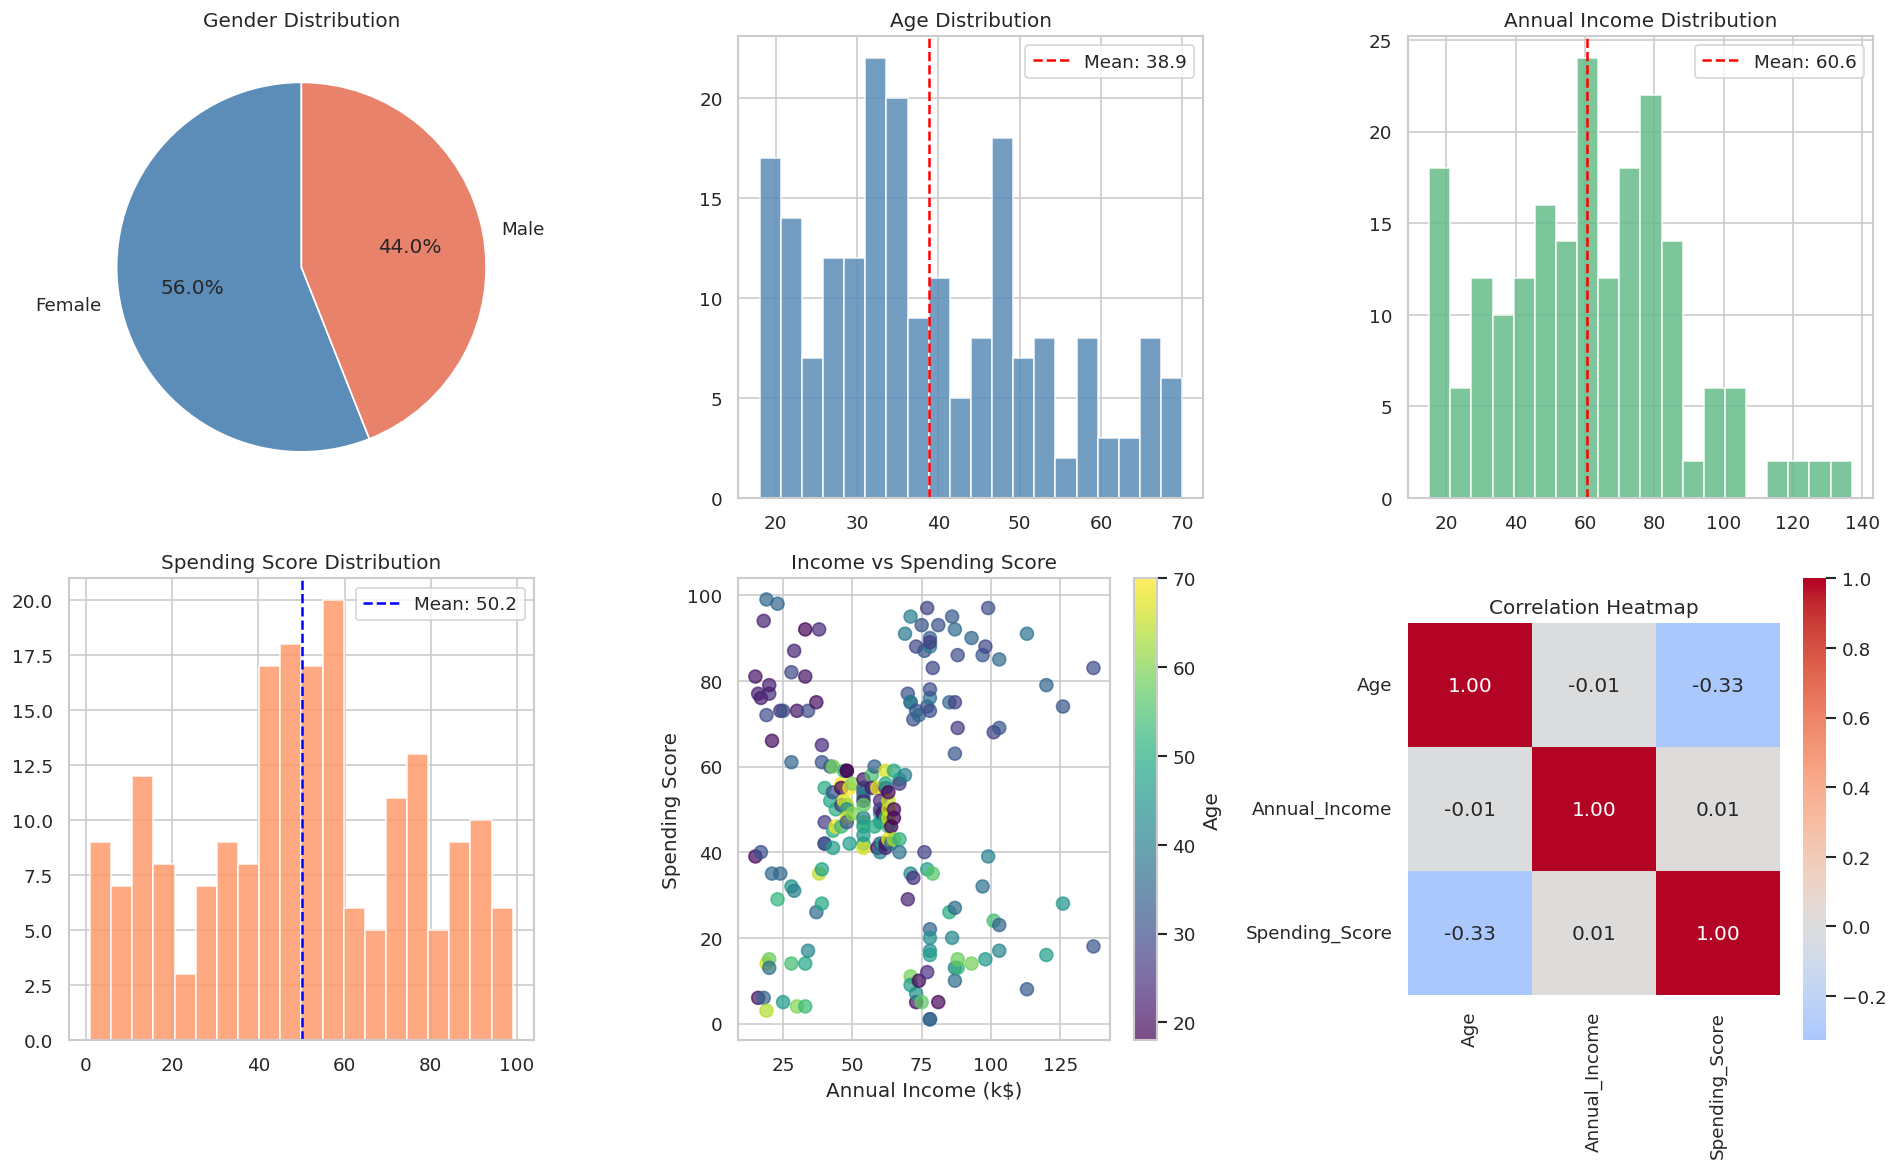

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

gender_counts = df['Gender'].value_counts()
axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
               colors=['#5B8DB8', '#E8826B'], startangle=90)
axes[0, 0].set_title('Gender Distribution')

axes[0, 1].hist(df['Age'], bins=20, color='#5B8DB8', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(df['Age'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 1].set_title('Age Distribution')
axes[0, 1].legend()

axes[0, 2].hist(df['Annual_Income'], bins=20, color='#66BB8A', edgecolor='white', alpha=0.85)
axes[0, 2].axvline(df['Annual_Income'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['Annual_Income'].mean():.1f}")
axes[0, 2].set_title('Annual Income Distribution')
axes[0, 2].legend()

axes[1, 0].hist(df['Spending_Score'], bins=20, color='#FF9A6C', edgecolor='white', alpha=0.85)
axes[1, 0].axvline(df['Spending_Score'].mean(), color='blue', linestyle='--',
                    label=f"Mean: {df['Spending_Score'].mean():.1f}")
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].legend()

scatter = axes[1, 1].scatter(df['Annual_Income'], df['Spending_Score'],
                              c=df['Age'], cmap='viridis', alpha=0.7, s=60)
plt.colorbar(scatter, ax=axes[1, 1], label='Age')
axes[1, 1].set_title('Income vs Spending Score')
axes[1, 1].set_xlabel('Annual Income (k$)')
axes[1, 1].set_ylabel('Spending Score')

corr = df[['Age', 'Annual_Income', 'Spending_Score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 2], center=0, square=True)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
df['Gender_Encoded'] = (df['Gender'] == 'Female').astype(int)

features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(pd.DataFrame(X_scaled, columns=features).describe().round(3))
print("done")

           Age  Annual_Income  Spending_Score
count  200.000        200.000         200.000
mean    -0.000         -0.000          -0.000
std      1.003          1.003           1.003
min     -1.496         -1.739          -1.910
25%     -0.725         -0.728          -0.600
50%     -0.205          0.036          -0.008
75%      0.728          0.666           0.885
max      2.236          2.918           1.894
done


k=2  inertia=389.39  silhouette=0.3355
k=3  inertia=295.21  silhouette=0.3578
k=4  inertia=205.23  silhouette=0.4040
k=5  inertia=168.25  silhouette=0.4166
k=6  inertia=133.87  silhouette=0.4274
k=7  inertia=117.01  silhouette=0.4172
k=8  inertia=103.83  silhouette=0.4087
k=9  inertia=92.53  silhouette=0.4196
k=10  inertia=82.39  silhouette=0.4066
k=11  inertia=72.63  silhouette=0.4086


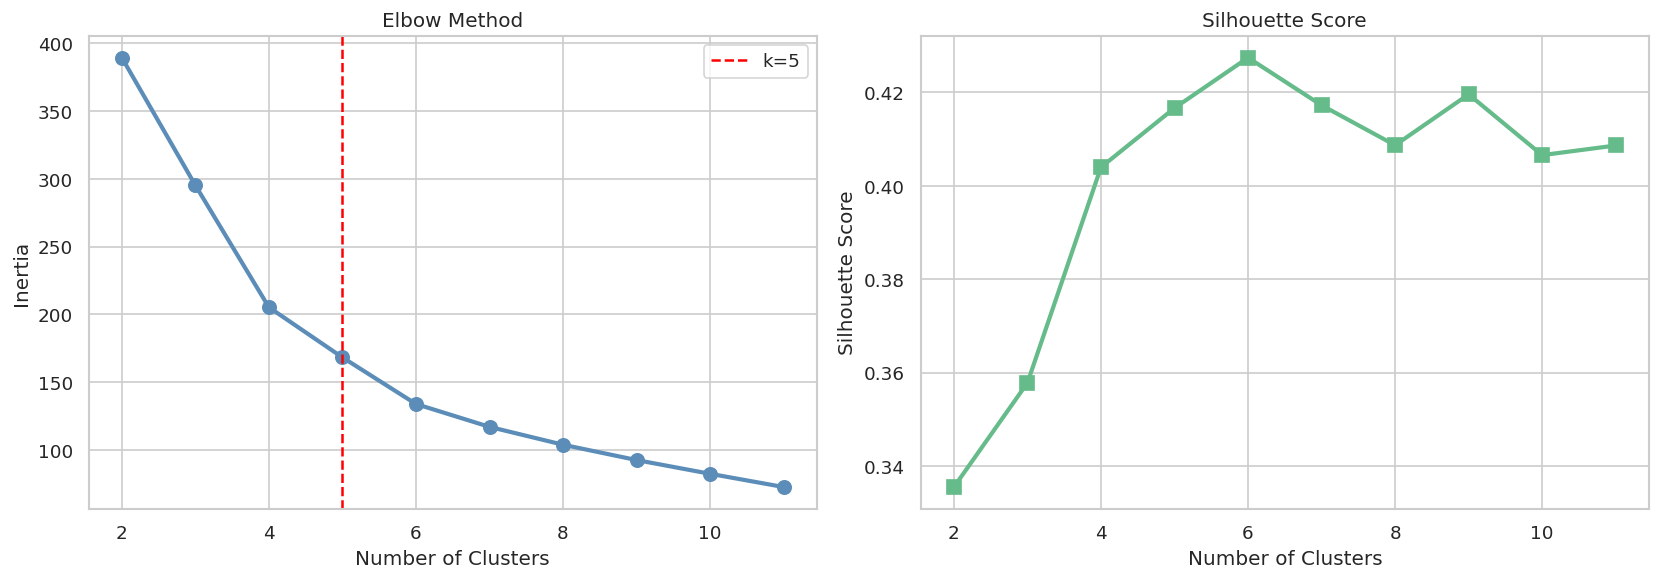

In [20]:
inertias = []
sil_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15,
                max_iter=500, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={sil_scores[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'o-', color='#5B8DB8', linewidth=2.5, markersize=8)
ax1.axvline(x=5, color='red', linestyle='--', label='k=5')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.legend()

ax2.plot(K_range, sil_scores, 's-', color='#66BB8A', linewidth=2.5, markersize=8)
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

BEST_K = 5

In [22]:
km_final = KMeans(n_clusters=BEST_K, init='k-means++', n_init=20,
                  max_iter=500, random_state=42)
km_final.fit(X_scaled)
df['Cluster'] = km_final.labels_

final_sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Inertia    : {km_final.inertia_:.2f}")
print(f"Silhouette : {final_sil:.4f}")
print(df['Cluster'].value_counts().sort_index())

Inertia    : 168.25
Silhouette : 0.4166
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


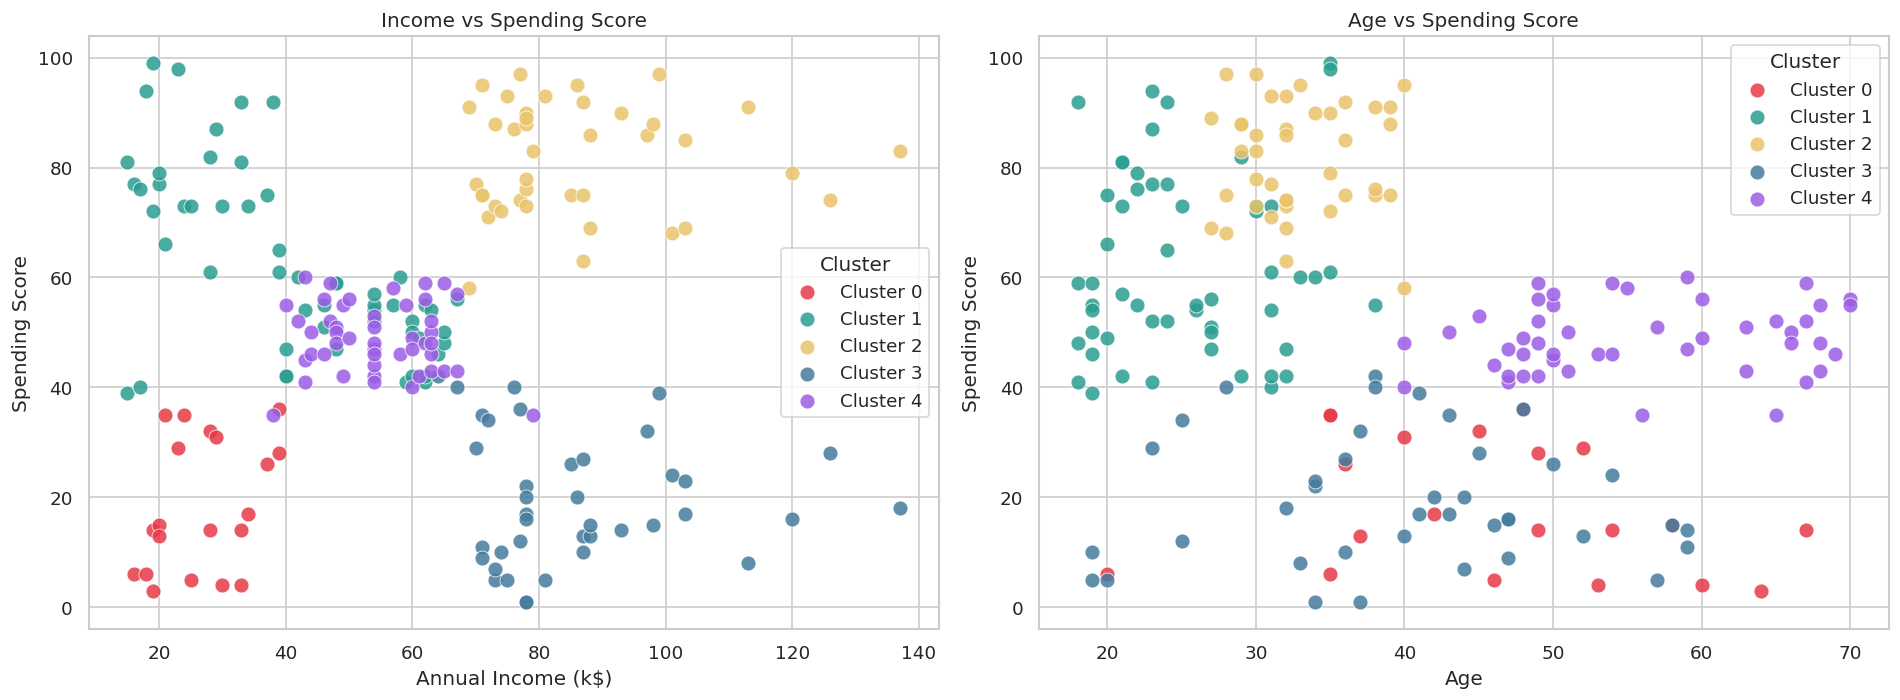

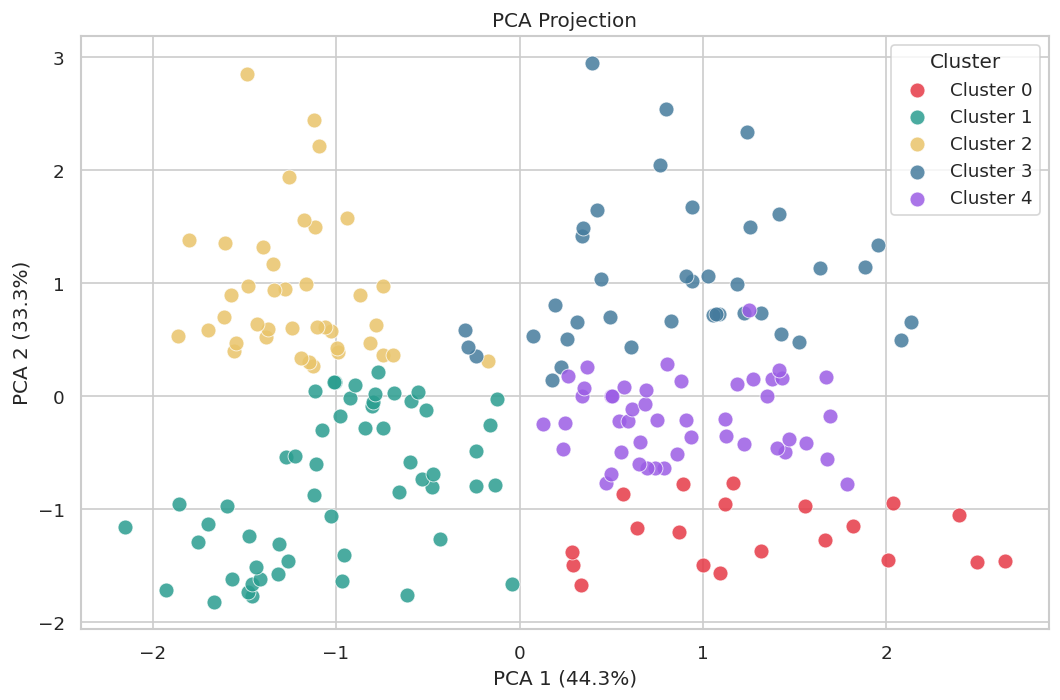

In [23]:
COLORS = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#9B5DE5']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for c in range(BEST_K):
    mask = df['Cluster'] == c
    ax1.scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
                color=COLORS[c], label=f'Cluster {c}', s=80, alpha=0.85,
                edgecolors='white', linewidths=0.5)

ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score')
ax1.set_title('Income vs Spending Score')
ax1.legend(title='Cluster')

for c in range(BEST_K):
    mask = df['Cluster'] == c
    ax2.scatter(df.loc[mask, 'Age'], df.loc[mask, 'Spending_Score'],
                color=COLORS[c], label=f'Cluster {c}', s=80, alpha=0.85,
                edgecolors='white', linewidths=0.5)

ax2.set_xlabel('Age')
ax2.set_ylabel('Spending Score')
ax2.set_title('Age vs Spending Score')
ax2.legend(title='Cluster')

plt.tight_layout()
plt.savefig('clusters_2d.png', bbox_inches='tight', dpi=150)
plt.show()

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(BEST_K):
    mask = df['Cluster'] == c
    ax.scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
               color=COLORS[c], label=f'Cluster {c}', s=80, alpha=0.85,
               edgecolors='white', linewidths=0.5)

ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('clusters_pca.png', bbox_inches='tight', dpi=150)
plt.show()

fig3d = px.scatter_3d(df, x='Age', y='Annual_Income', z='Spending_Score',
                      color=df['Cluster'].astype(str), symbol='Gender',
                      color_discrete_sequence=COLORS,
                      title='3D Cluster View')
fig3d.update_traces(marker=dict(size=5))
fig3d.write_html('clusters_3d.html')
fig3d.show()

         Count  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
Cluster                                                      
0           20    46.25       26.75         18.35        60.0
1           54    25.19       41.09         62.24        59.0
2           40    32.88       86.10         81.53        55.0
3           39    39.87       86.10         19.36        49.0
4           47    55.64       54.38         48.85        57.0


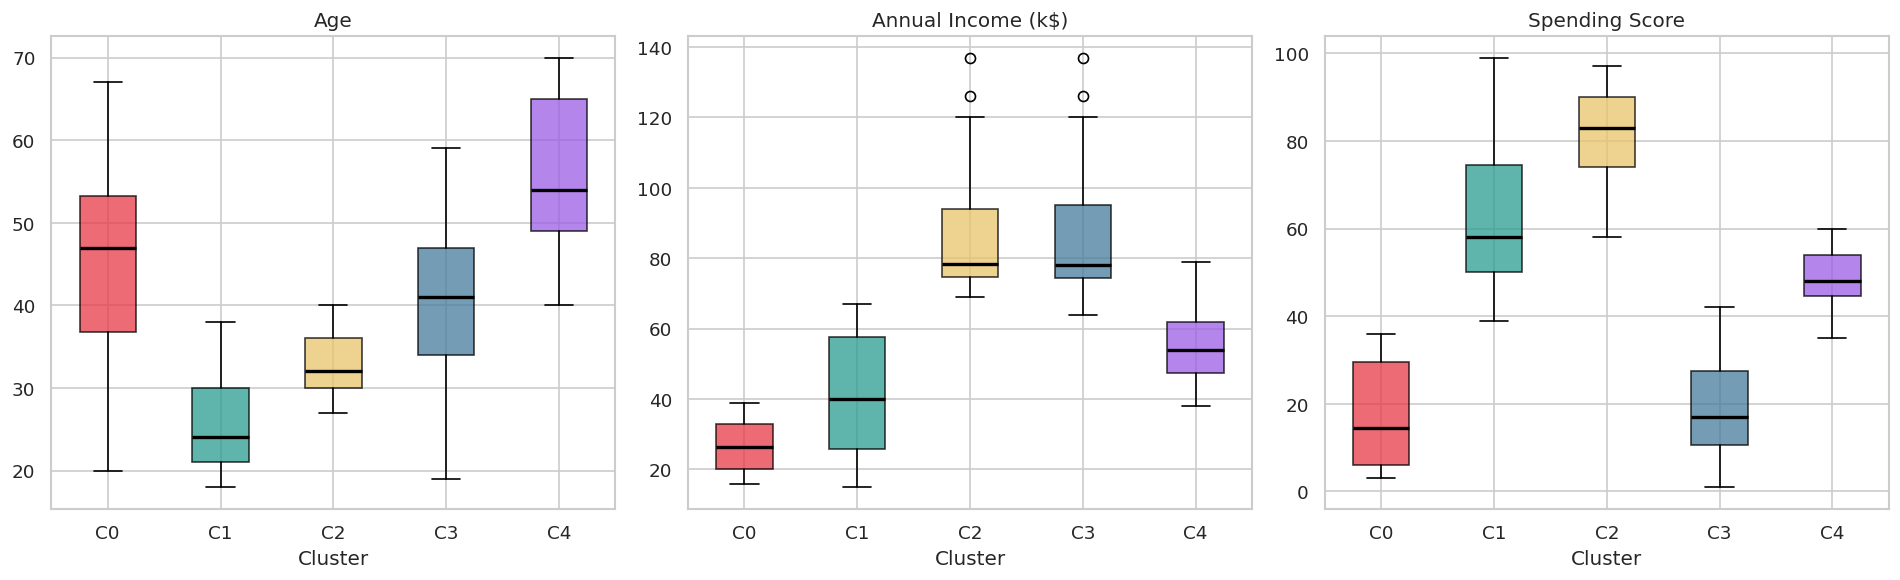

In [24]:
profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Female_Pct=('Gender_Encoded', 'mean')
).round(2)

profile['Female_Pct'] = (profile['Female_Pct'] * 100).round(1)
print(profile)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, label) in enumerate(zip(
        ['Age', 'Annual_Income', 'Spending_Score'],
        ['Age', 'Annual Income (k$)', 'Spending Score'])):
    data_by_cluster = [df[df['Cluster'] == c][col].values for c in range(BEST_K)]
    bp = axes[i].boxplot(data_by_cluster, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[i].set_title(label)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticklabels([f'C{c}' for c in range(BEST_K)])

plt.tight_layout()
plt.savefig('cluster_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

In [25]:
output_cols = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score', 'Cluster']
df[output_cols].to_csv('/kaggle/working/customers_with_clusters.csv', index=False)

profile_out = df.groupby('Cluster').agg(
    Size=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Female_Pct=('Gender_Encoded', lambda x: round(x.mean() * 100, 1))
).round(2).reset_index()

profile_out.to_csv('/kaggle/working/cluster_summary.csv', index=False)
print(profile_out)

   Cluster  Size  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
0        0    20    46.25       26.75         18.35        60.0
1        1    54    25.19       41.09         62.24        59.3
2        2    40    32.88       86.10         81.53        55.0
3        3    39    39.87       86.10         19.36        48.7
4        4    47    55.64       54.38         48.85        57.4


In [27]:
segments = {
    0: (
        "Low Income Low Spenders",
        "Age ~46, income ~27k$, spending ~18. Older, budget-conscious customers. "
        "Strategy: value deals, discount loyalty cards, affordable product lines."
    ),
    1: (
        "Young Active Spenders",
        "Age ~25, income ~41k$, spending ~62. Young customers spending above their means. "
        "Strategy: trendy products, EMI options, social media campaigns, BOGO offers."
    ),
    2: (
        "High Value Premium Customers",
        "Age ~33, income ~86k$, spending ~82. Best segment — high income and high spending. "
        "Strategy: VIP programs, premium upsells, exclusive events, personalized offers."
    ),
    3: (
        "Cautious High Earners",
        "Age ~40, income ~86k$, spending ~19. High income but not spending. Hard to convert. "
        "Strategy: trust-building content, quality guarantees, reviews, targeted flash sales."
    ),
    4: (
        "Average Middle Segment",
        "Age ~56, income ~54k$, spending ~49. Largest stable group. Moderate in everything. "
        "Strategy: referral programs, seasonal discounts, loyalty points, newsletters."
    ),
}

cluster_stats = df.groupby('Cluster').agg(
    Size=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean')
).round(1)

for cid, (name, strategy) in segments.items():
    stats = cluster_stats.loc[cid]
    print(f"\nCluster {cid} — {name}")
    print(f"  Size       : {int(stats['Size'])} ({int(stats['Size'])/len(df)*100:.1f}%)")
    print(f"  Avg Age    : {stats['Avg_Age']}")
    print(f"  Avg Income : {stats['Avg_Income']}k$")
    print(f"  Avg Spend  : {stats['Avg_Spending']}/100")
    print(f"  Strategy   : {strategy}")

print(f"\nSilhouette Score : {final_sil:.4f}")
print(f"Total Customers  : {len(df)}")


Cluster 0 — Low Income Low Spenders
  Size       : 20 (10.0%)
  Avg Age    : 46.2
  Avg Income : 26.8k$
  Avg Spend  : 18.4/100
  Strategy   : Age ~46, income ~27k$, spending ~18. Older, budget-conscious customers. Strategy: value deals, discount loyalty cards, affordable product lines.

Cluster 1 — Young Active Spenders
  Size       : 54 (27.0%)
  Avg Age    : 25.2
  Avg Income : 41.1k$
  Avg Spend  : 62.2/100
  Strategy   : Age ~25, income ~41k$, spending ~62. Young customers spending above their means. Strategy: trendy products, EMI options, social media campaigns, BOGO offers.

Cluster 2 — High Value Premium Customers
  Size       : 40 (20.0%)
  Avg Age    : 32.9
  Avg Income : 86.1k$
  Avg Spend  : 81.5/100
  Strategy   : Age ~33, income ~86k$, spending ~82. Best segment — high income and high spending. Strategy: VIP programs, premium upsells, exclusive events, personalized offers.

Cluster 3 — Cautious High Earners
  Size       : 39 (19.5%)
  Avg Age    : 39.9
  Avg Income : 86.